# Univariate forecasting with `numpyro_forecast`

Here we present an introduction to the `numpyro_forecast` package. This notebook ports the blog post [**Univariate time series forecasting with NumPyro**](https://juanitorduz.github.io/numpyro_forecasting-univariate/) (itself a port of Pyro's [forecasting tutorial](https://pyro.ai/examples/forecasting_i.html)) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. We forecast **weekly BART ridership** with a random-walk local level, Fourier seasonality and a Student-T likelihood, fit with stochastic variational inference (SVI), and evaluate with the continuous ranked probability score (CRPS).

Instead of hand-writing the NumPyro model and a bespoke prediction loop, we subclass `numpyro_forecast.forecaster.ForecastingModel` and let `Forecaster` handle the *fit-once / forecast-any-horizon* mechanics (the forecast horizon is drawn from separate `_future` latent sites, so the variational guide is never resized).

> **Note on reproducibility.** We match the blog's data, seed, optimizer and step counts. Results reproduce the blog's behavior and CRPS magnitude but are not bit-for-bit identical: the forecast horizon uses the package's separate-`_future`-site mechanism (rather than re-running the guide over the full covariates), and the seasonal design uses `fourier_features`, an equivalent Fourier basis.

## Prepare notebook

In [1]:
from functools import partial

import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import Predictive
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import Adam

from numpyro_forecast import Forecaster, ForecastingModel, backtest, eval_coverage, eval_crps
from numpyro_forecast.datasets import load_bart_weekly
from numpyro_forecast.functional import Horizon, forecasting_model, predict, time_series
from numpyro_forecast.typing import Array
from numpyro_forecast.util import fourier_features

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Read data

We work with total **weekly** BART ridership: hourly counts summed over all origin-destination pairs and aggregated into non-overlapping weeks. The series grows roughly multiplicatively, so we model it on the log scale, where the trend and the seasonal swings are closer to additive. Throughout the package, time lives at axis `-2` and the observation dimension at axis `-1`, so a single series has shape `(weeks, 1)`.

data shape: (469, 1)


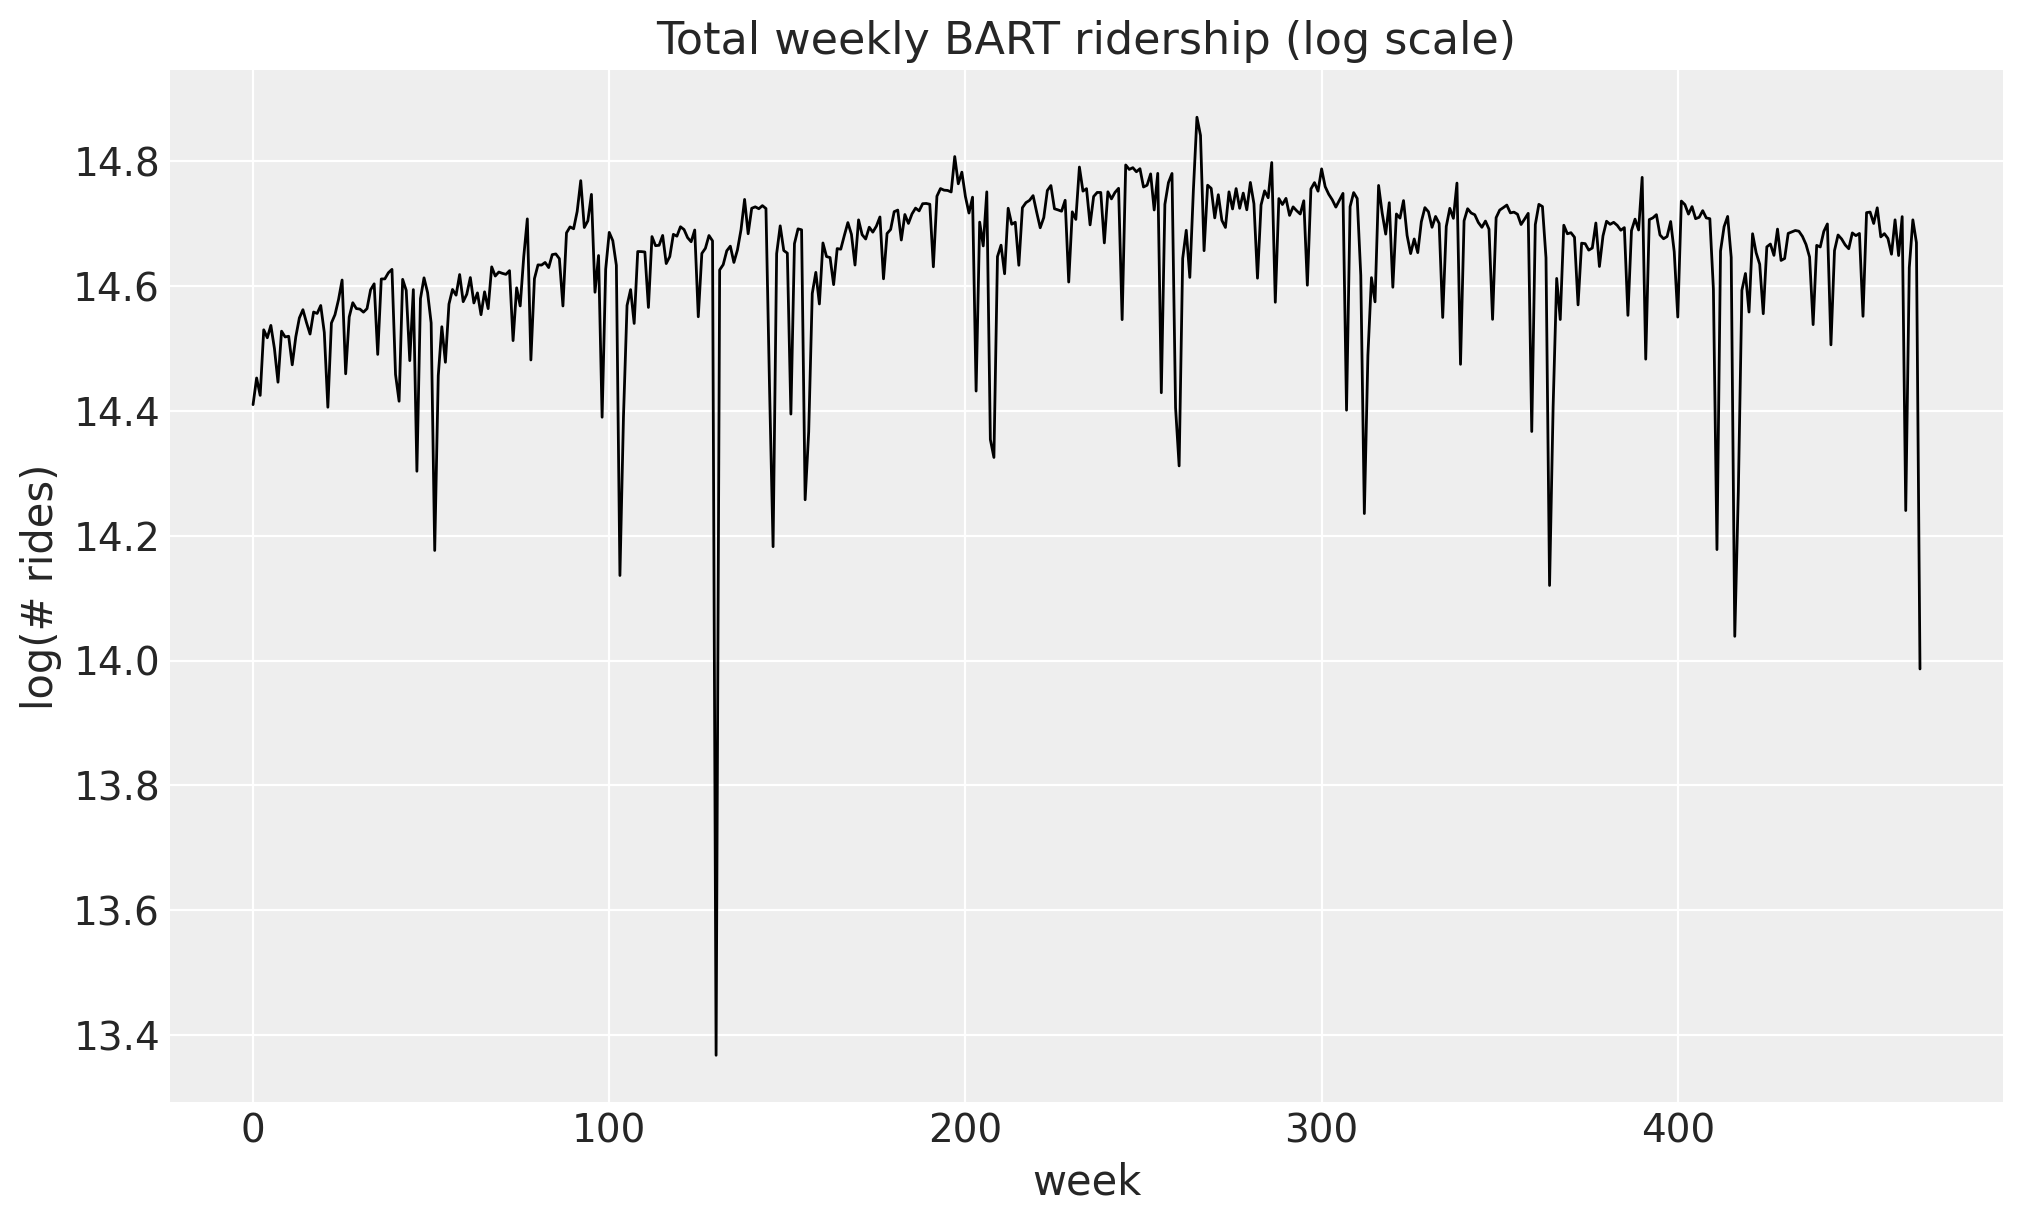

In [2]:
data = load_bart_weekly()  # (weeks, 1), log scale
duration = data.shape[0]
print("data shape:", data.shape)

fig, ax = plt.subplots()
ax.plot(np.asarray(data[:, 0]), color="black", lw=1)
ax.set(
    title="Total weekly BART ridership (log scale)",
    xlabel="week",
    ylabel="log(# rides)",
);

## Train-test split

We hold out the last `52` weeks (one full year) as the test set and train on the preceding `417` weeks. Keeping a whole year out means the test window covers a complete seasonal cycle, which is exactly where a seasonal model can over- or under-fit.

train: (417, 1) test: (52, 1)


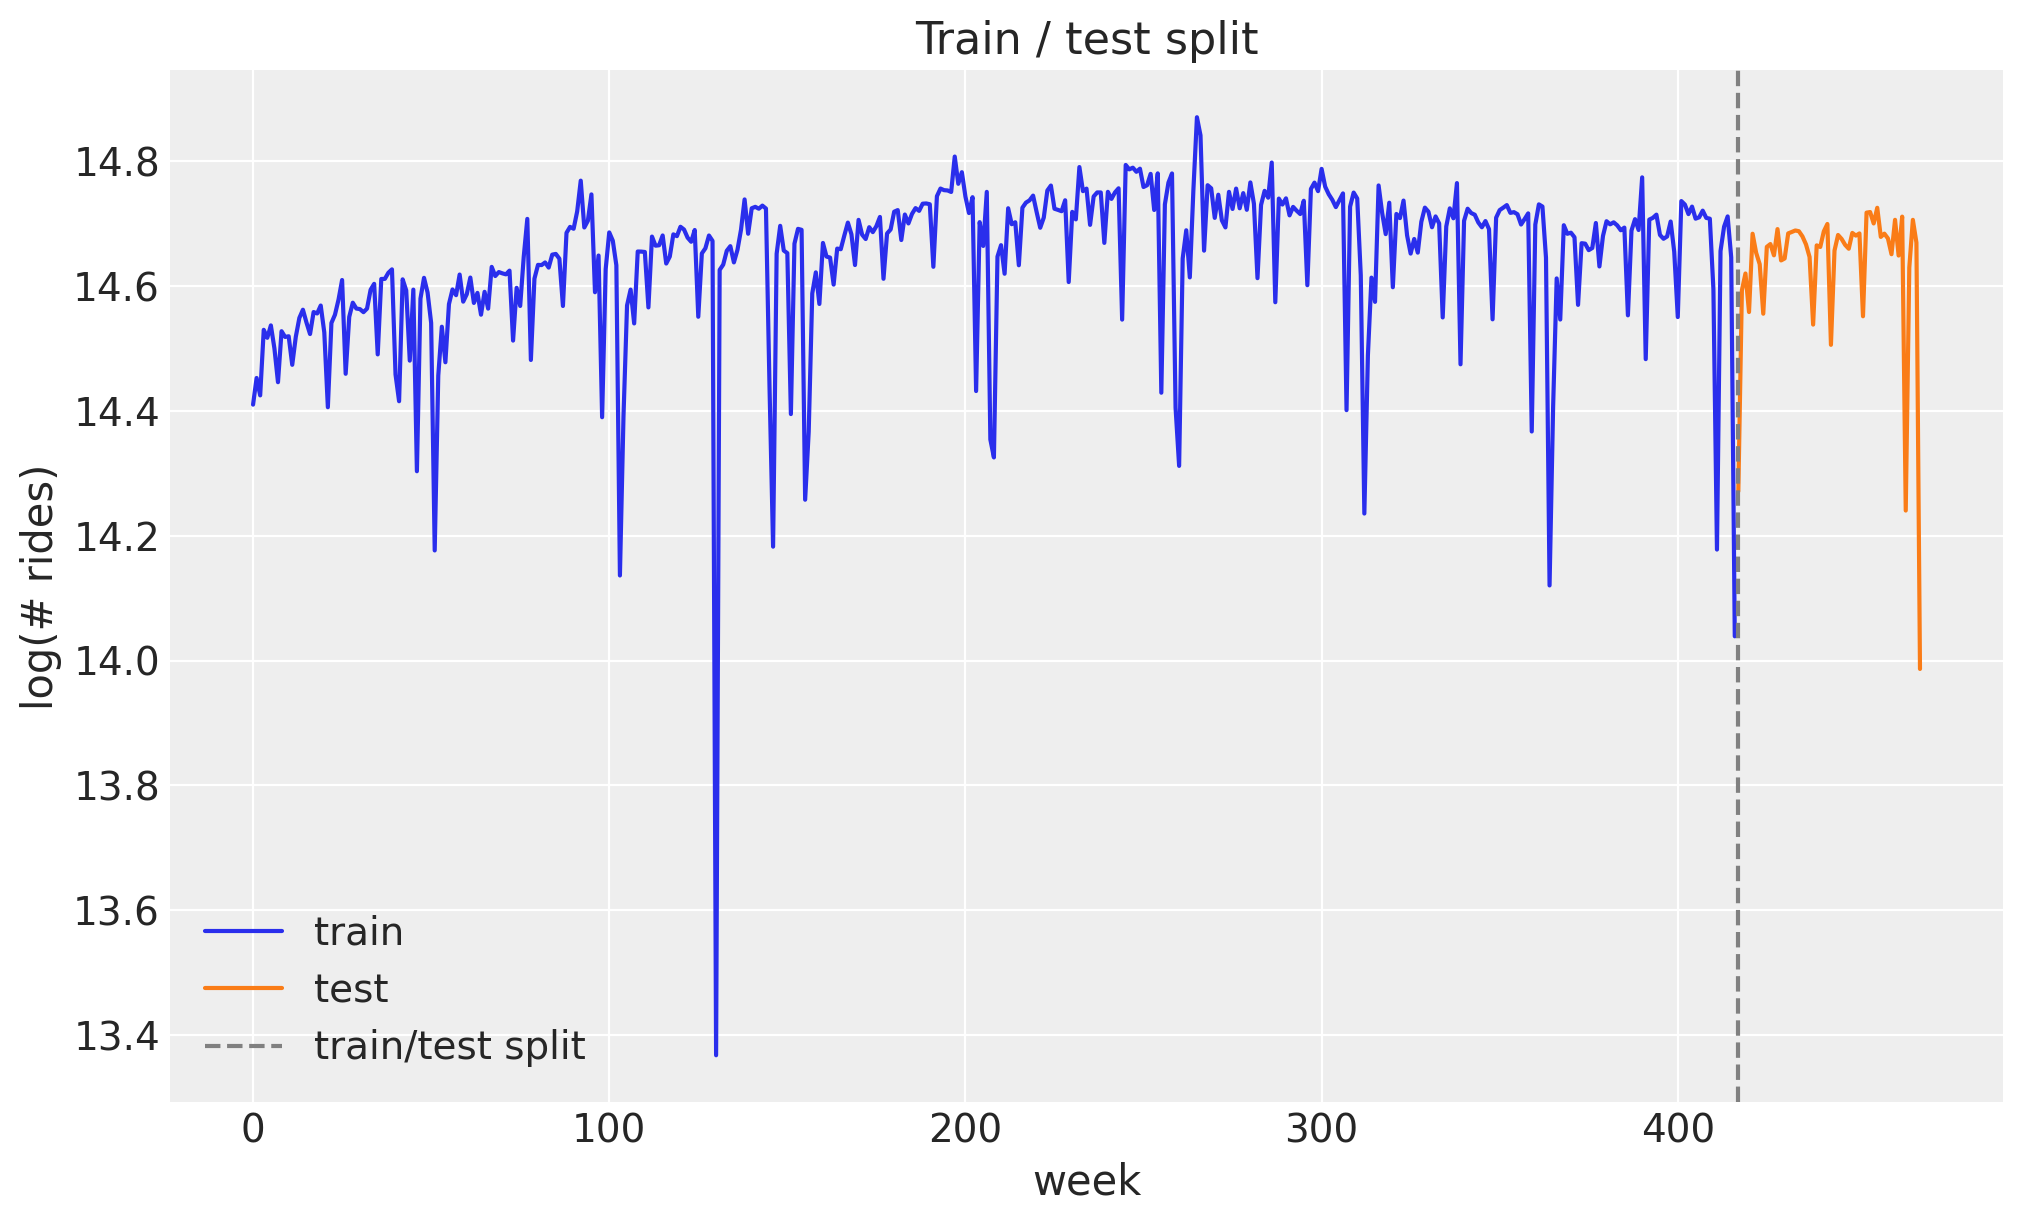

In [3]:
T0 = 0
T2 = duration  # 469
T1 = T2 - 52  # 417: train / test split

y_train = data[T0:T1]
y_test = data[T1:T2]

time = np.arange(T2)
time_train = time[T0:T1]
time_test = time[T1:T2]
print("train:", y_train.shape, "test:", y_test.shape)

fig, ax = plt.subplots()
ax.plot(time_train, np.asarray(y_train[:, 0]), color="C0", label="train")
ax.plot(time_test, np.asarray(y_test[:, 0]), color="C1", label="test")
ax.axvline(T1, color="gray", ls="--", label="train/test split")
ax.legend()
ax.set(title="Train / test split", xlabel="week", ylabel="log(# rides)");

## Seasonal features

To capture the annual cycle we use a **Fourier** design matrix: `26` harmonics (so `52` sine and cosine columns) at a period of `365.25 / 7` weeks. Each harmonic is a sine/cosine pair at a multiple of the base frequency, and a weighted sum of them can approximate any smooth periodic shape. This spans the same subspace as the blog's `periodic_features`, so paired with the `Normal(0, 0.1)` weight prior the regression is equivalent. The plot below shows the first few low-frequency modes.

covariates shape: (469, 52)


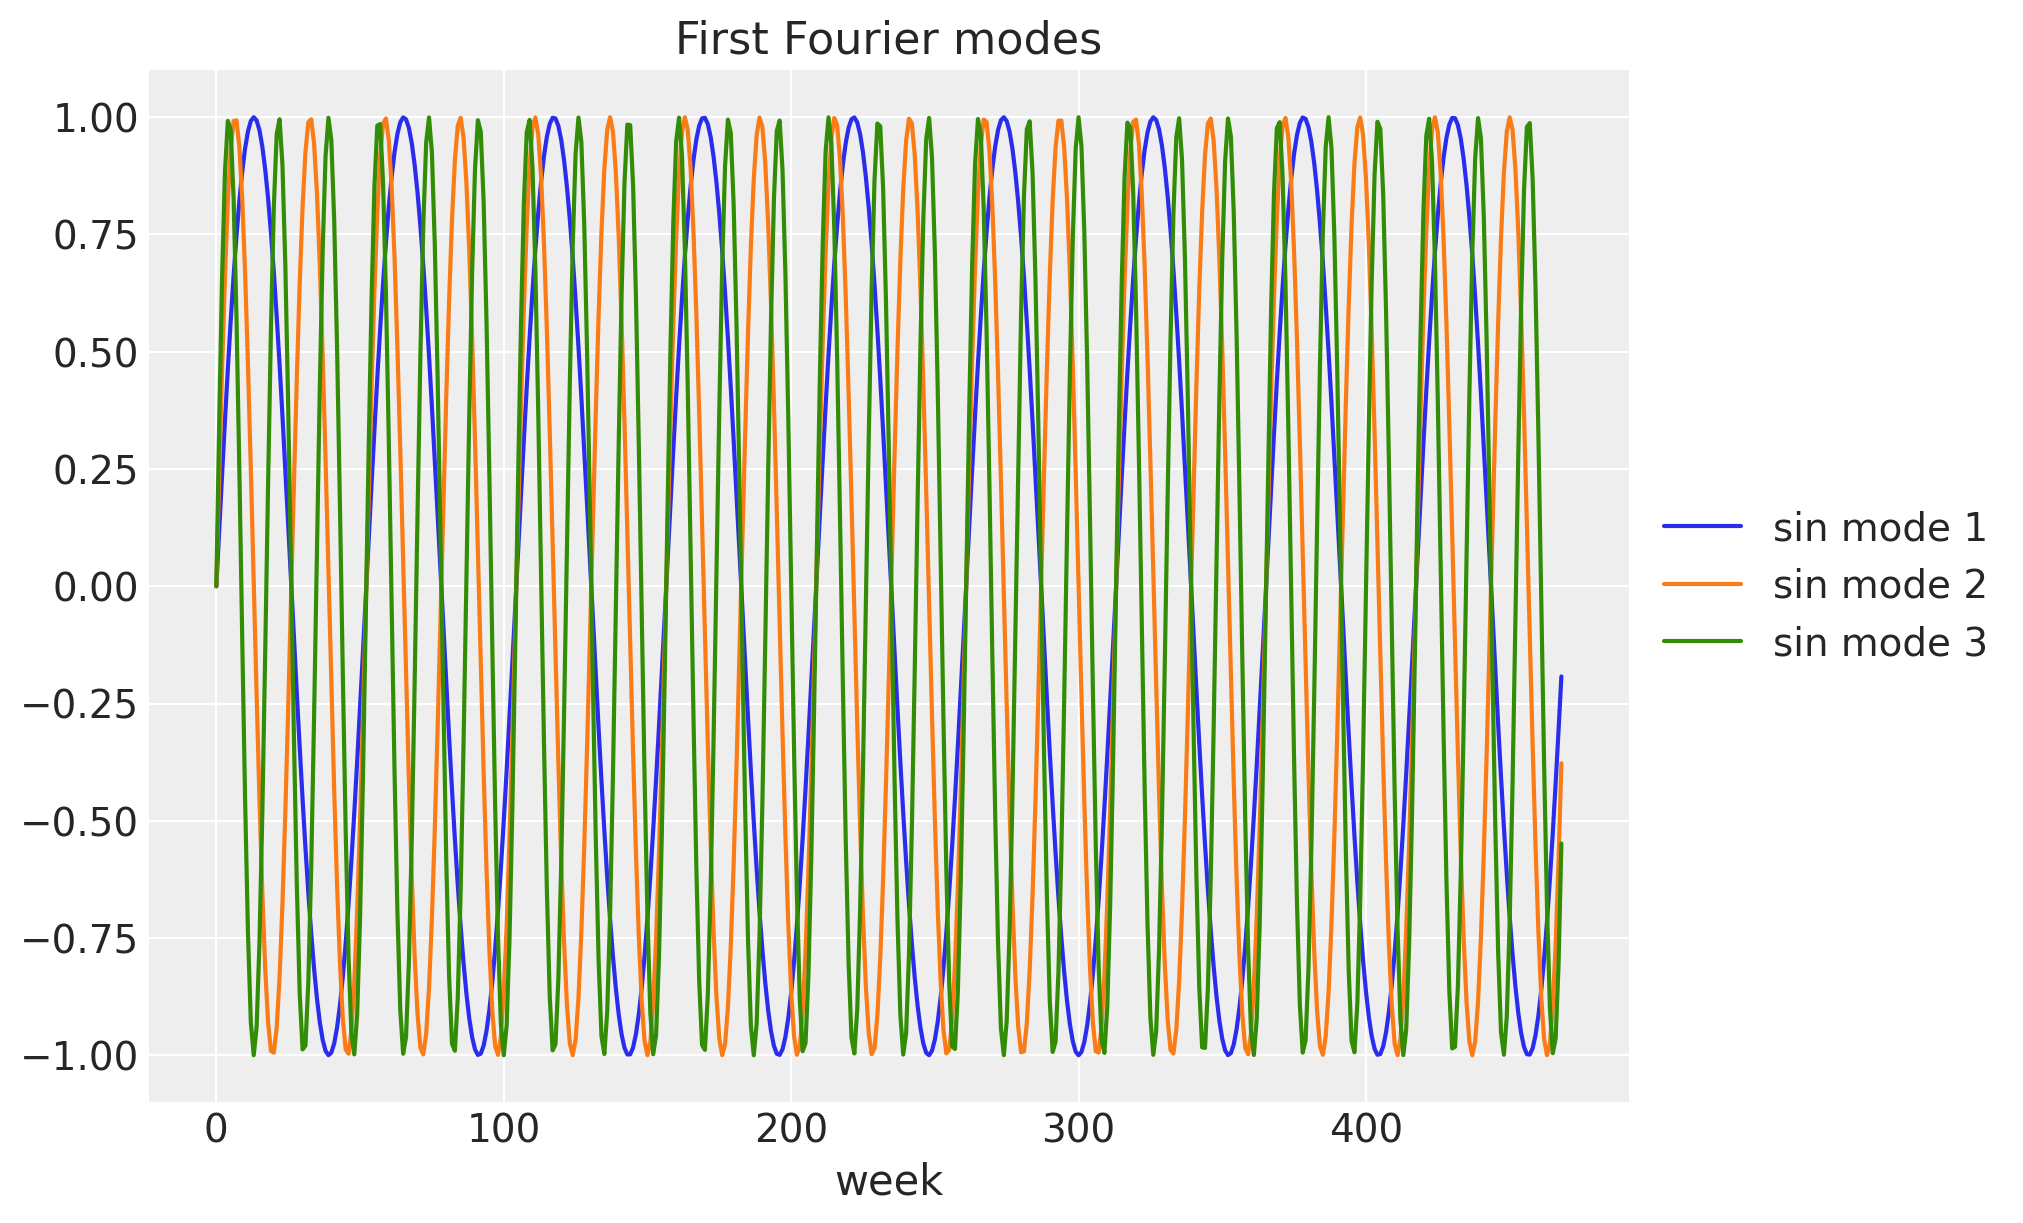

In [4]:
num_terms = 26
covariates = fourier_features(duration, period=365.25 / 7, num_terms=num_terms)
covariates_train = covariates[T0:T1]
print("covariates shape:", covariates.shape)

fig, ax = plt.subplots()
for k in range(3):
    ax.plot(np.asarray(covariates[:, k]), label=f"sin mode {k + 1}")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="First Fourier modes", xlabel="week");

## Model specification

The idea is a *local level model with seasonality*. The mean has three parts: a global `bias`, a random-walk level $\ell_t$ that lets the baseline drift slowly over time, and a Fourier regression for the annual cycle. The level moves by small Gaussian increments (the `drift`), so it can follow long-term changes without being told their shape in advance. For the likelihood we use a Student-T instead of a Normal: its heavy tails make the model robust to the occasional outlier week.

\begin{align*}
\mu_t  & = \text{bias} + \ell_t + w^\top x_t, \\
\ell_t & = \ell_{t-1} + \delta_t, \\
\delta_t & \sim \text{Normal}(0, \sigma_\text{drift}), \\
y_t & \sim \text{StudentT}(\nu, \mu_t, \sigma).
\end{align*}

We subclass `ForecastingModel` and write the generative story in `model`. The level is the cumulative sum of `drift`, which we sample with `self.time_series(...)` (the package's equivalent of the blog's `scan` over time). The single call to `self.predict(...)` registers the zero-centered Student-T noise around the predicted mean, and it is also what wires up the train-vs-forecast machinery: in-sample steps are observed, while the forecast horizon is drawn from separate `_future` latent sites so the variational guide never changes shape. Finally, a `LocScaleReparam` on the drift switches between centered and non-centered parameterizations, which helps the SVI geometry quite a lot.

In [5]:
class UnivariateForecaster(ForecastingModel):
    """Local level + Fourier regression with Student-T observations."""

    def model(self, zero_data: Array | None, covariates: Array) -> None:
        """Define the univariate forecasting model."""
        num_features = covariates.shape[-1]

        bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
        weight = numpyro.sample("weight", dist.Normal(0.0, 0.1).expand([num_features]).to_event(1))
        drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
        nu = numpyro.sample("nu", dist.Gamma(10.0, 2.0))
        sigma = numpyro.sample("sigma", dist.LogNormal(-5.0, 5.0))
        centered = numpyro.sample("centered", dist.Uniform(0.0, 1.0))

        drift = self.time_series(
            "drift",
            lambda: dist.Normal(0.0, drift_scale),
            reparam=LocScaleReparam(centered=centered),
        )
        level = jnp.cumsum(drift, axis=-2)
        regression = (weight * covariates).sum(axis=-1, keepdims=True)
        prediction = level + bias + regression

        self.predict(dist.StudentT(df=nu, loc=0.0, scale=sigma), prediction)

Let's visualize the model:

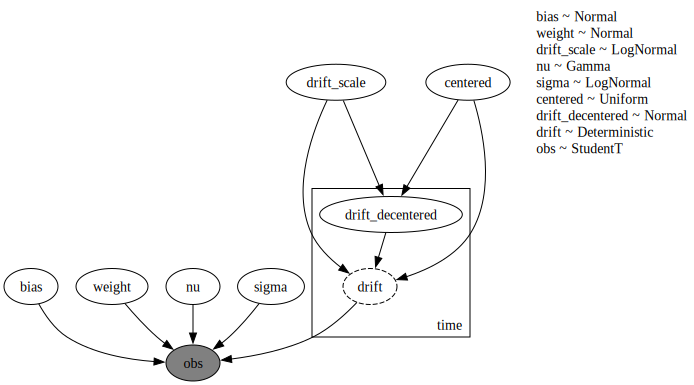

In [6]:
numpyro.render_model(
    UnivariateForecaster(),
    model_args=(covariates_train, y_train),
    render_distributions=True,
)

## Prior predictive checks

As usual (highly recommended!), we look at the prior predictive before fitting anything. We draw from the prior over the training window (`data=None`, so the horizon is zero and the `obs` site spans the train period) and plot the $50\%$ and $94\%$ HDI bands against the training series with ArviZ `plot_lm`. The priors are not very informative, but the implied ranges sit comfortably around the data, which is what we want.

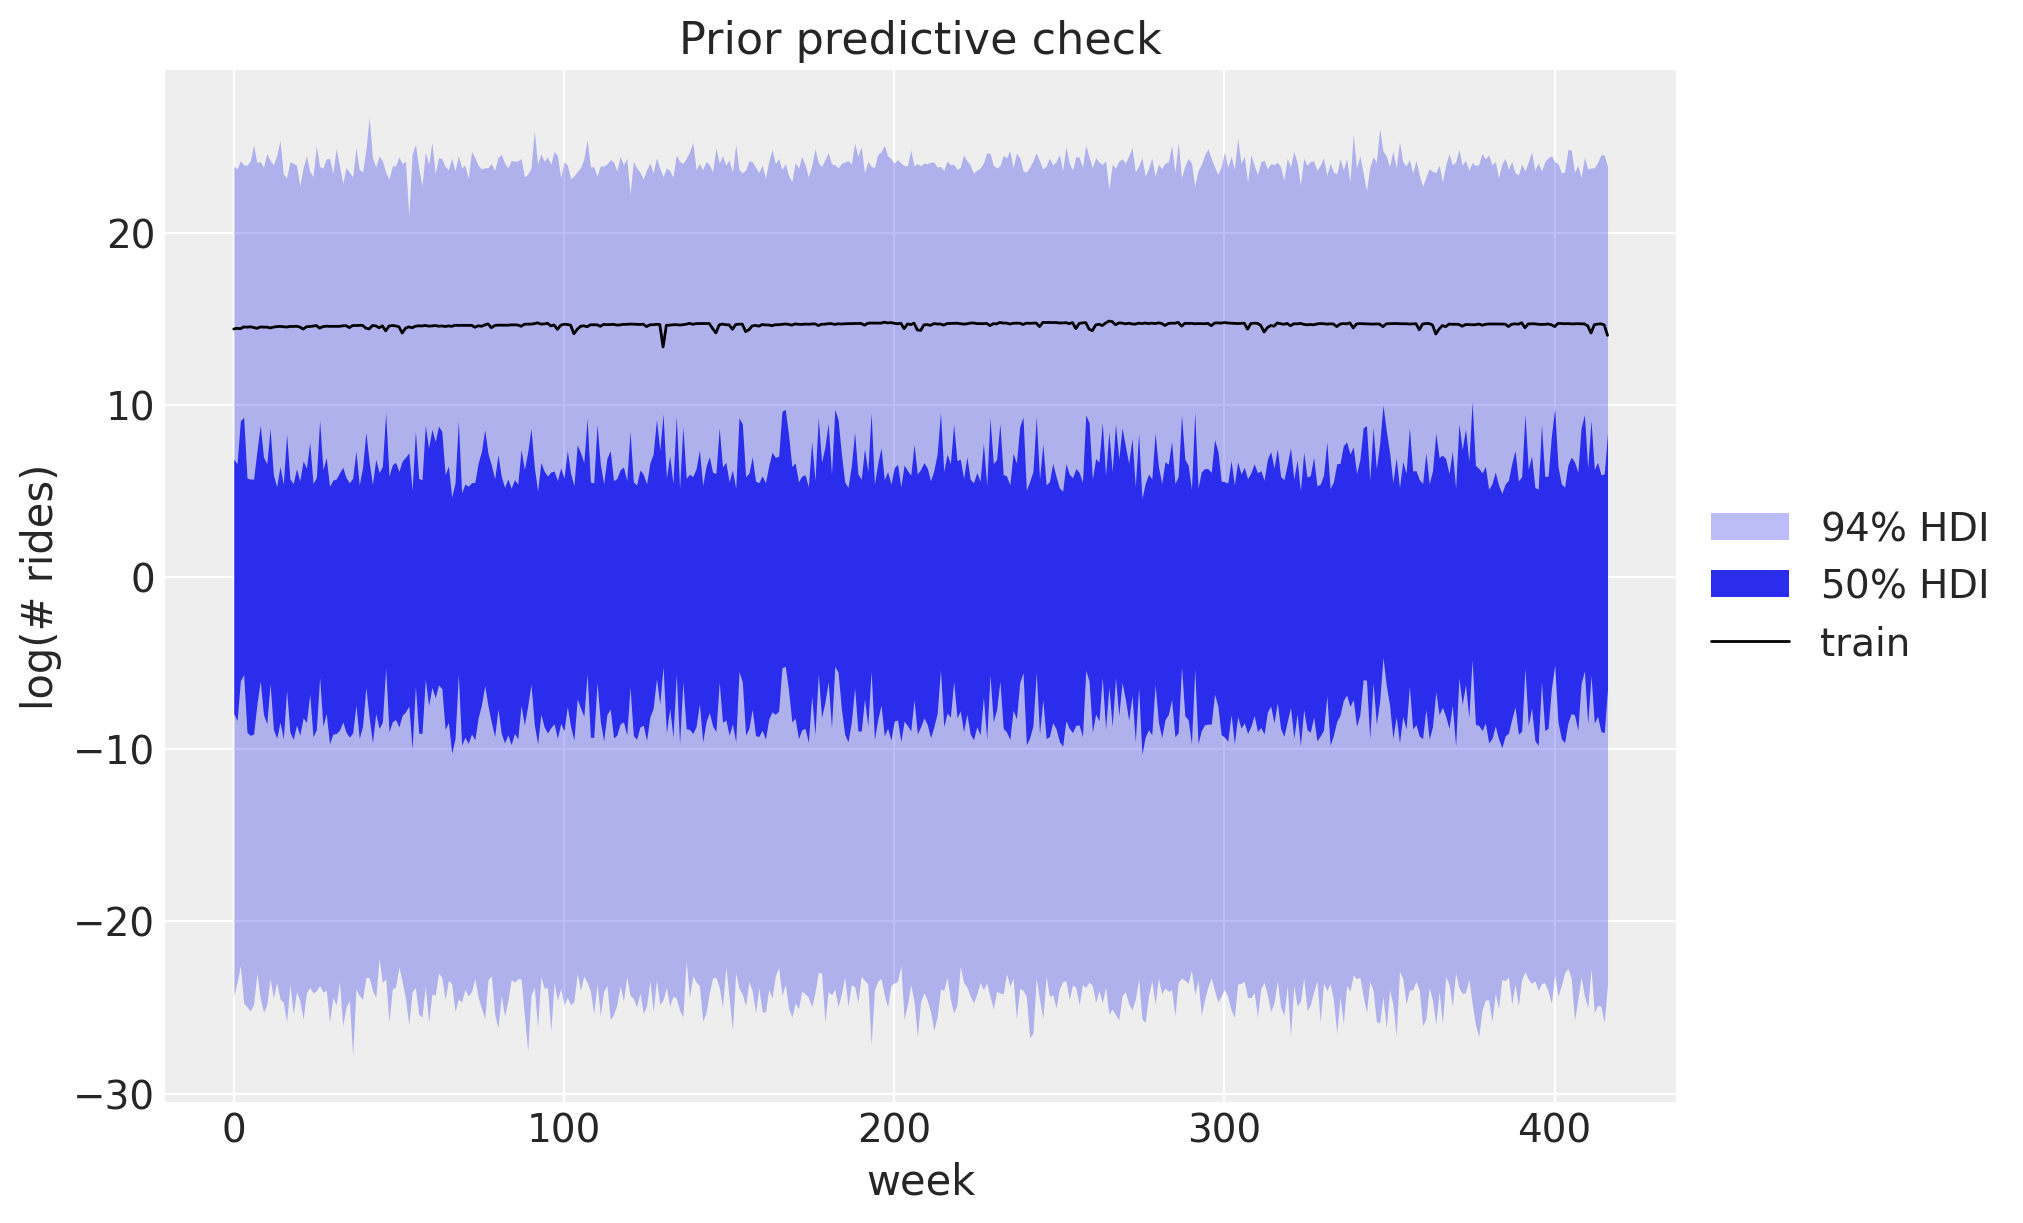

In [7]:
prior_predictive = Predictive(UnivariateForecaster(), num_samples=2_000, return_sites=["obs"])
rng_key, rng_subkey = random.split(rng_key)
prior_obs = prior_predictive(rng_subkey, covariates_train)["obs"][..., 0]

idata_prior = az.from_dict(
    {
        "prior_predictive": {"obs": np.asarray(prior_obs)[None]},
        "observed_data": {"obs": np.asarray(y_train[:, 0])},
        "constant_data": {"week": time_train.astype(float)},
    },
    coords={"time": time_train.astype(float)},
    dims={"obs": ["time"], "week": ["time"]},
)
pc = az.plot_lm(
    idata_prior,
    y="obs",
    x="week",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
    },
    figure_kwargs={"figsize": (10, 6)},
)
ax = pc.viz["figure"].item().axes[0]
band_50, band_94 = ax.collections  # in ci_prob order: (0.5, 0.94)
band_50.set_label(r"$50\%$ HDI")
band_94.set_label(r"$94\%$ HDI")
(train_line,) = ax.plot(time_train, np.asarray(y_train[:, 0]), color="black", lw=1, label="train")
ax.legend(handles=[band_94, band_50, train_line], loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="Prior predictive check", ylabel="log(# rides)");

## Inference with SVI

We fit the model with stochastic variational inference. Passing the model and data to `Forecaster` runs SVI under the hood (an `AutoNormal` guide with `Adam`) and stores the fitted `guide`, `params` and the ELBO `losses`. The loss curve should decrease and flatten out, a quick sanity check that the optimization converged.

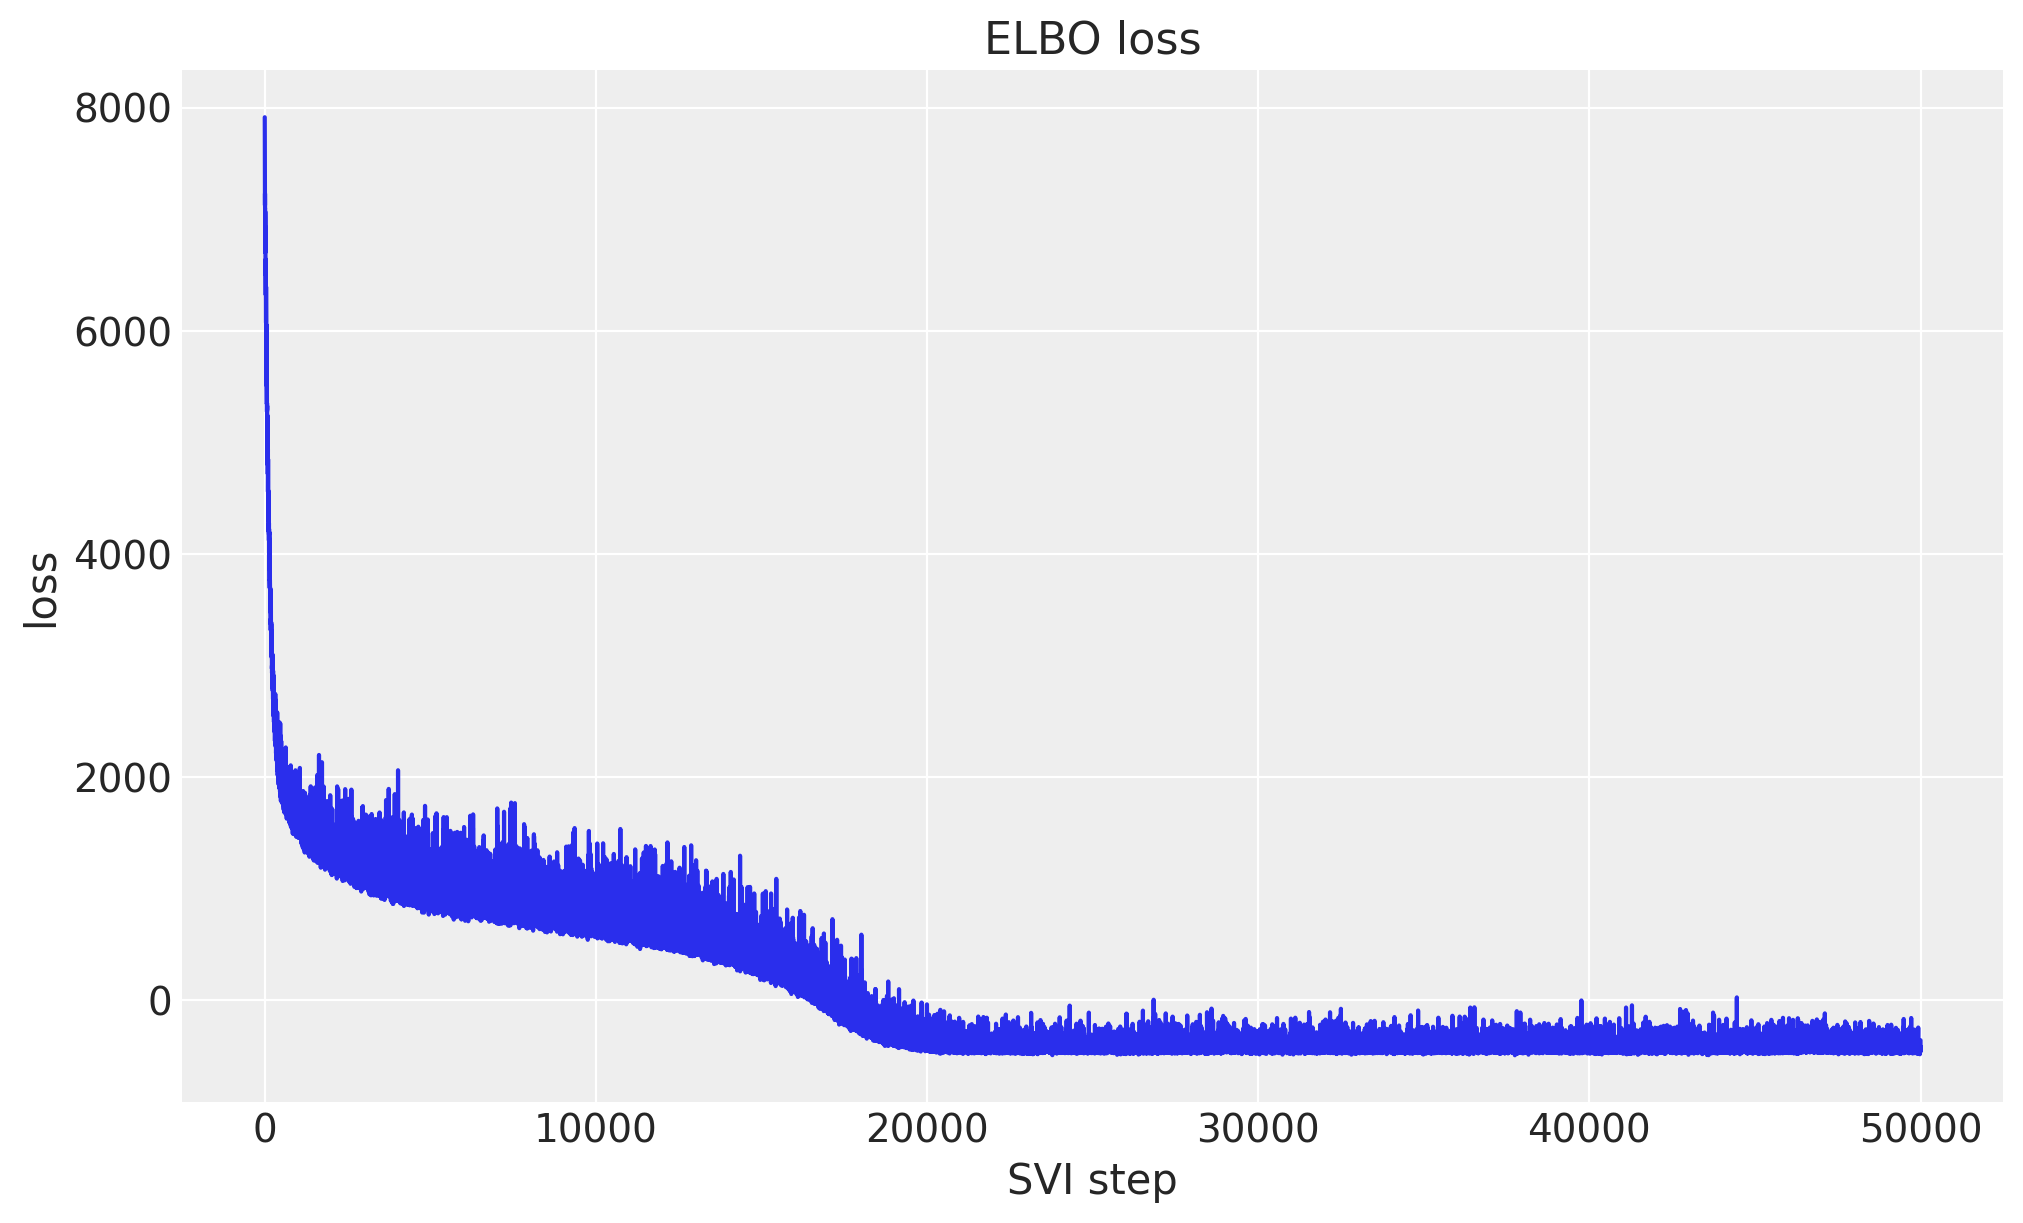

In [8]:
rng_key, rng_subkey = random.split(rng_key)
model = UnivariateForecaster()
forecaster = Forecaster(
    rng_subkey,
    model,
    y_train,
    covariates_train,
    optim=Adam(step_size=0.005),
    num_steps=50_000,
)

fig, ax = plt.subplots()
ax.plot(forecaster.losses)
ax.set(title="ELBO loss", xlabel="SVI step", ylabel="loss");

## Posterior predictive check

We now look at two things. First the **in-sample** posterior predictive over the training window: here the horizon is zero, so the guide is not resized and we just sample the `obs` site. Then the **forecast** over the test horizon with `forecaster(...)`, which continues the level from its inferred endpoint and draws the future random-walk increments from the prior.

To score both we use the **continuous ranked probability score** (CRPS), a proper scoring rule that compares a single ground-truth value to the whole forecast distribution rather than just a point estimate. It rewards forecasts that are both sharp and calibrated, and lower is better.

In [9]:
rng_key, key_pp, key_fc = random.split(rng_key, 3)

# In-sample posterior predictive over the training window.
train_pp = forecaster.predict_in_sample(key_pp, covariates_train, num_samples=5_000)

# Forecast over the test horizon.
forecast = forecaster(key_fc, y_train, covariates, num_samples=5_000)

crps_train = eval_crps(train_pp, y_train)
crps_test = eval_crps(forecast, y_test)
print(f"Train CRPS: {crps_train:.4f}")
print(f"Test CRPS:  {crps_test:.4f}")
print(f"Test 50% coverage: {eval_coverage(forecast, y_test, alpha=0.5):.2f}  (nominal 0.50)")
print(f"Test 94% coverage: {eval_coverage(forecast, y_test, alpha=0.94):.2f}  (nominal 0.94)")

Train CRPS: 0.0284
Test CRPS:  0.0347
Test 50% coverage: 0.63  (nominal 0.50)
Test 94% coverage: 0.92  (nominal 0.94)


## Forecast visualization

The combined view puts everything together: the in-sample posterior predictive (blue) and the forecast over the held-out year (orange), each with $50\%$ and $94\%$ HDI bands, against the observed series. The forecast tracks the seasonal pattern and the uncertainty widens into the future, as it should.

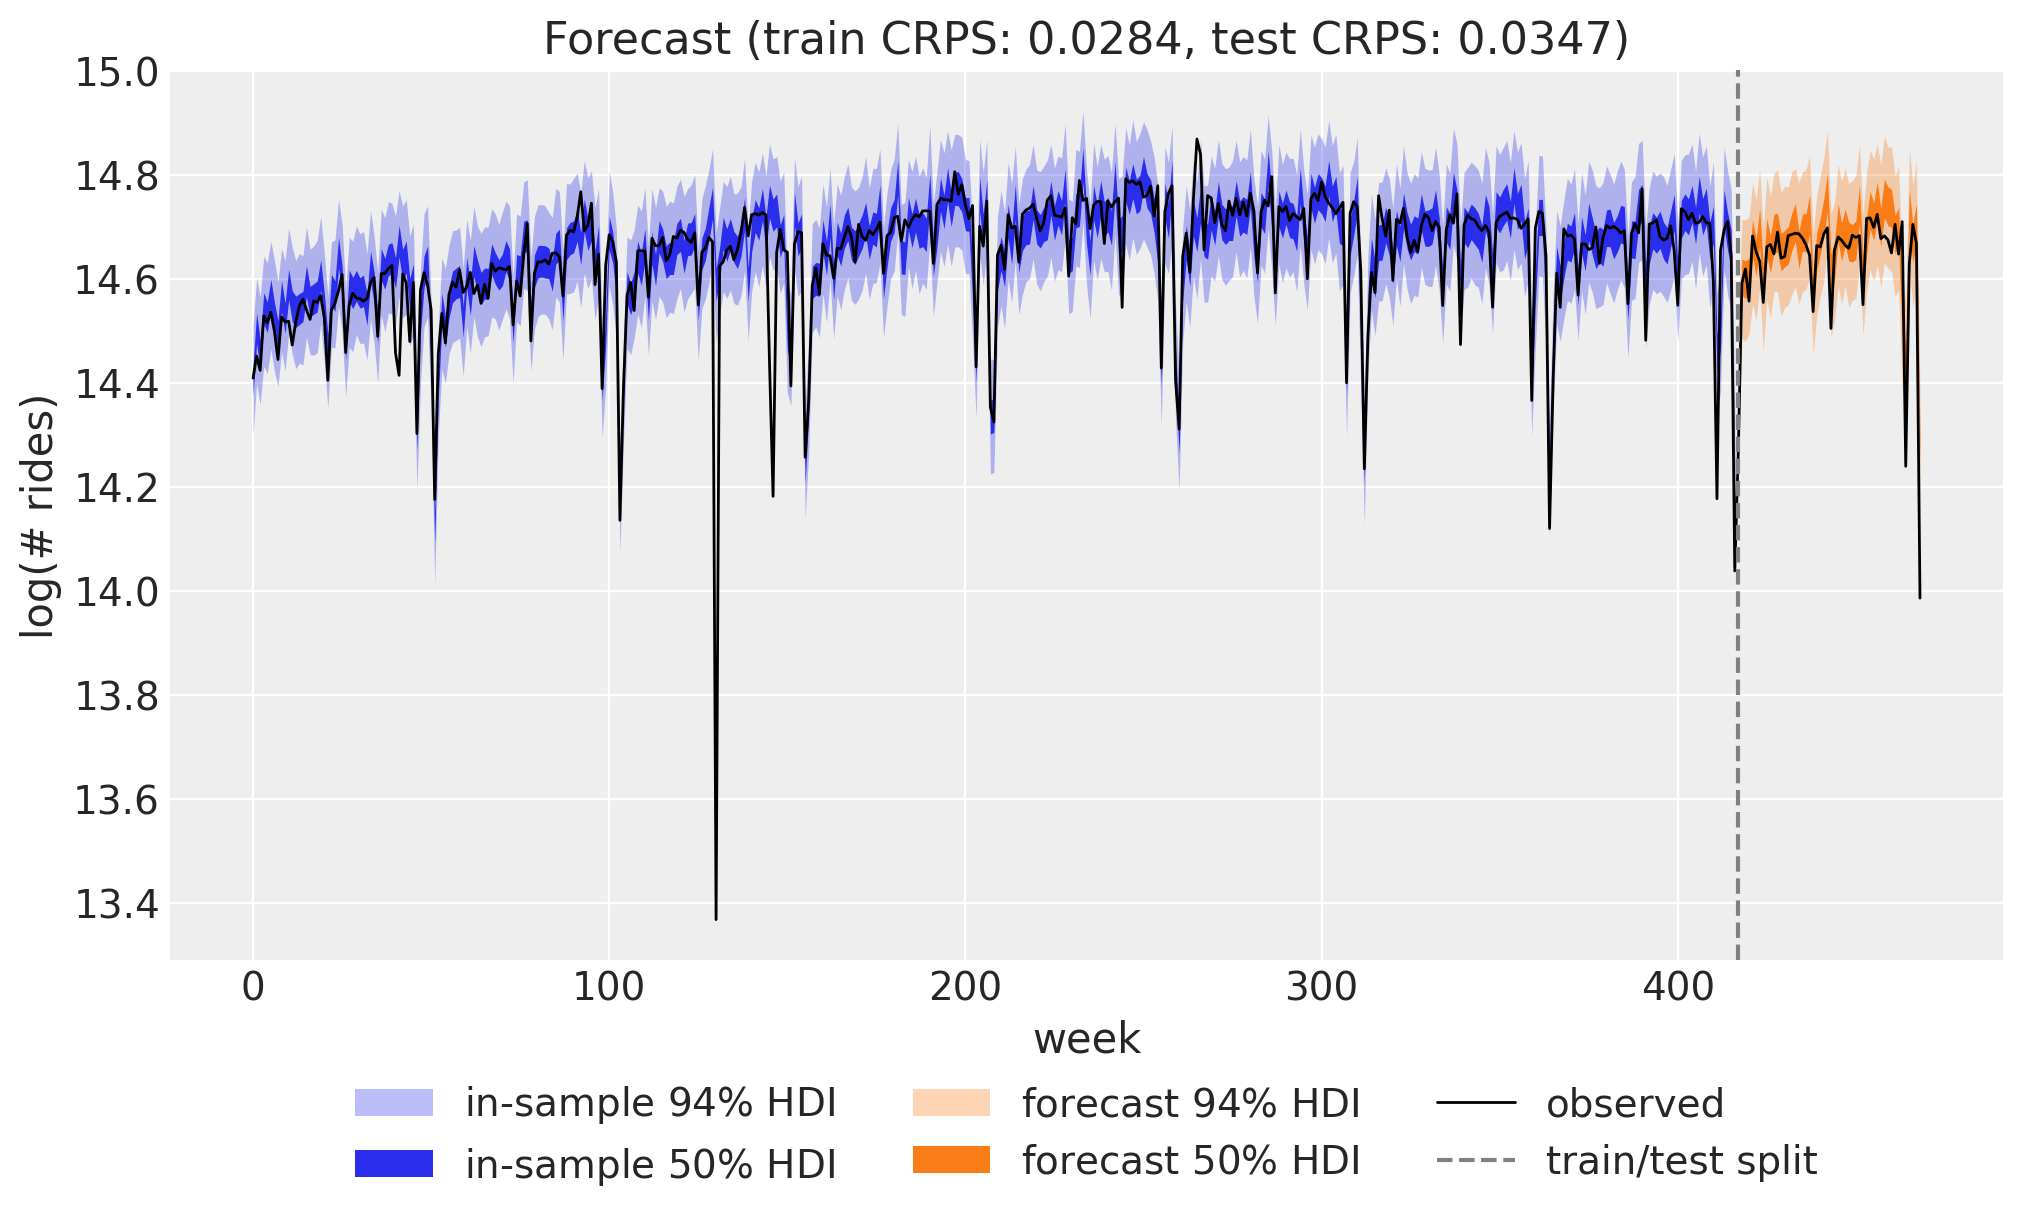

In [10]:
train_obs = train_pp[..., 0]
forecast_obs = forecast[..., 0]

idata_train = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(train_obs)[None]},
        "observed_data": {"obs": np.asarray(y_train[:, 0])},
        "constant_data": {"week": time_train.astype(float)},
    },
    coords={"time": time_train.astype(float)},
    dims={"obs": ["time"], "week": ["time"]},
)
idata_test = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(forecast_obs)[None]},
        "observed_data": {"obs": np.asarray(y_test[:, 0])},
        "constant_data": {"week": time_test.astype(float)},
    },
    coords={"time": time_test.astype(float)},
    dims={"obs": ["time"], "week": ["time"]},
)

pc = az.plot_lm(
    idata_train,
    y="obs",
    x="week",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (10, 6)},
)
az.plot_lm(
    idata_test,
    y="obs",
    x="week",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
)
ax = pc.viz["figure"].item().axes[0]
# ax.collections holds the bands in plotting order: train (0.5, 0.94) then test (0.5, 0.94).
band_train_50, band_train_94, band_test_50, band_test_94 = ax.collections
band_train_94.set_label(r"in-sample $94\%$ HDI")
band_train_50.set_label(r"in-sample $50\%$ HDI")
band_test_94.set_label(r"forecast $94\%$ HDI")
band_test_50.set_label(r"forecast $50\%$ HDI")
(obs_line,) = ax.plot(time, np.asarray(data[:, 0]), color="black", lw=1, label="observed")
split_line = ax.axvline(T1, color="gray", ls="--", label="train/test split")
ax.legend(
    handles=[band_train_94, band_train_50, band_test_94, band_test_50, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(
    title=f"Forecast (train CRPS: {crps_train:.4f}, test CRPS: {crps_test:.4f})",
    ylabel="log(# rides)",
);

## Rolling-origin backtesting

A single train/test split tells us how the model did on one held-out year. A more honest picture of generalization comes from *rolling-origin* backtesting: we repeatedly move the train/test boundary forward, refit, and forecast the next window, so every later part of the series is scored out-of-sample exactly once. `numpyro_forecast.backtest` runs this loop on the full series for us, refitting a fresh `UnivariateForecaster` per fold.

We use an expanding window: each fold trains on everything up to its split point and forecasts the next `52` weeks (`test_window=52`), stepping forward a full year at a time (`stride=52`) so the folds do not overlap and the forecast overlay stays readable. The first `min_train_window=104` weeks (two years) seed the initial training window, matching Pyro's tutorial. With `eval_train=True` we also score the in-sample posterior predictive of each fold with the same CRPS metric, and `keep_predictions=True` retains each fold's out-of-sample forecast samples so we can plot them. Both options default to off, keeping the default `backtest` API faithful to Pyro.

One practical point: because every fold is refit from scratch, each one needs enough optimization to converge. We give SVI `num_steps=50_000` per fold (the same budget as the main fit) so that the larger expanding windows are fit just as well as the small early ones, which keeps the inferred drift volatility stable and the per-fold scores comparable. With too small a budget the later windows would be under-fit, inflating `drift_scale` so that both the forecast bands and the in-sample CRPS grow spuriously with window length.

In [11]:
num_backtest_samples = 2_000

metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rng_key, rng_subkey = random.split(rng_key)
results = backtest(
    rng_subkey,
    data,  # full dataset, no train/test split
    covariates,  # full covariates
    UnivariateForecaster,
    metrics=metrics,
    test_window=52,  # 1-year horizon per fold
    stride=52,  # non-overlapping folds for a clean plot_lm panel
    min_train_window=104,  # 2 years before the first fold, matching Pyro's start
    num_samples=num_backtest_samples,
    eval_train=True,
    keep_predictions=True,
    forecaster_options={"optim": Adam(step_size=0.005), "num_steps": 50_000},
)

split_weeks = [r.t1 for r in results]
insample_crps = [r.train_metrics["crps"] for r in results]
oos_crps = [r.metrics["crps"] for r in results]
oos_cov_50 = [r.metrics["coverage_50"] for r in results]
oos_cov_94 = [r.metrics["coverage_94"] for r in results]

print(f"folds: {len(results)}")
print(f"mean in-sample CRPS:     {np.mean(insample_crps):.4f}")
print(f"mean out-of-sample CRPS: {np.mean(oos_crps):.4f}")
print(f"mean out-of-sample 50% coverage: {np.mean(oos_cov_50):.2f}  (nominal 0.50)")
print(f"mean out-of-sample 94% coverage: {np.mean(oos_cov_94):.2f}  (nominal 0.94)")

folds: 7
mean in-sample CRPS:     0.0287
mean out-of-sample CRPS: 0.0375
mean out-of-sample 50% coverage: 0.57  (nominal 0.50)
mean out-of-sample 94% coverage: 0.95  (nominal 0.94)


### Rolling forecasts

Overlaying every fold's out-of-sample forecast (orange $50\%$ and $94\%$ HDI bands) on the full observed series gives the rolling-origin view: each band picks up where the previous fold's training data ended, so together they trace a continuous one-year-ahead forecast across the second half of the series. The dashed lines mark the successive train/test splits.

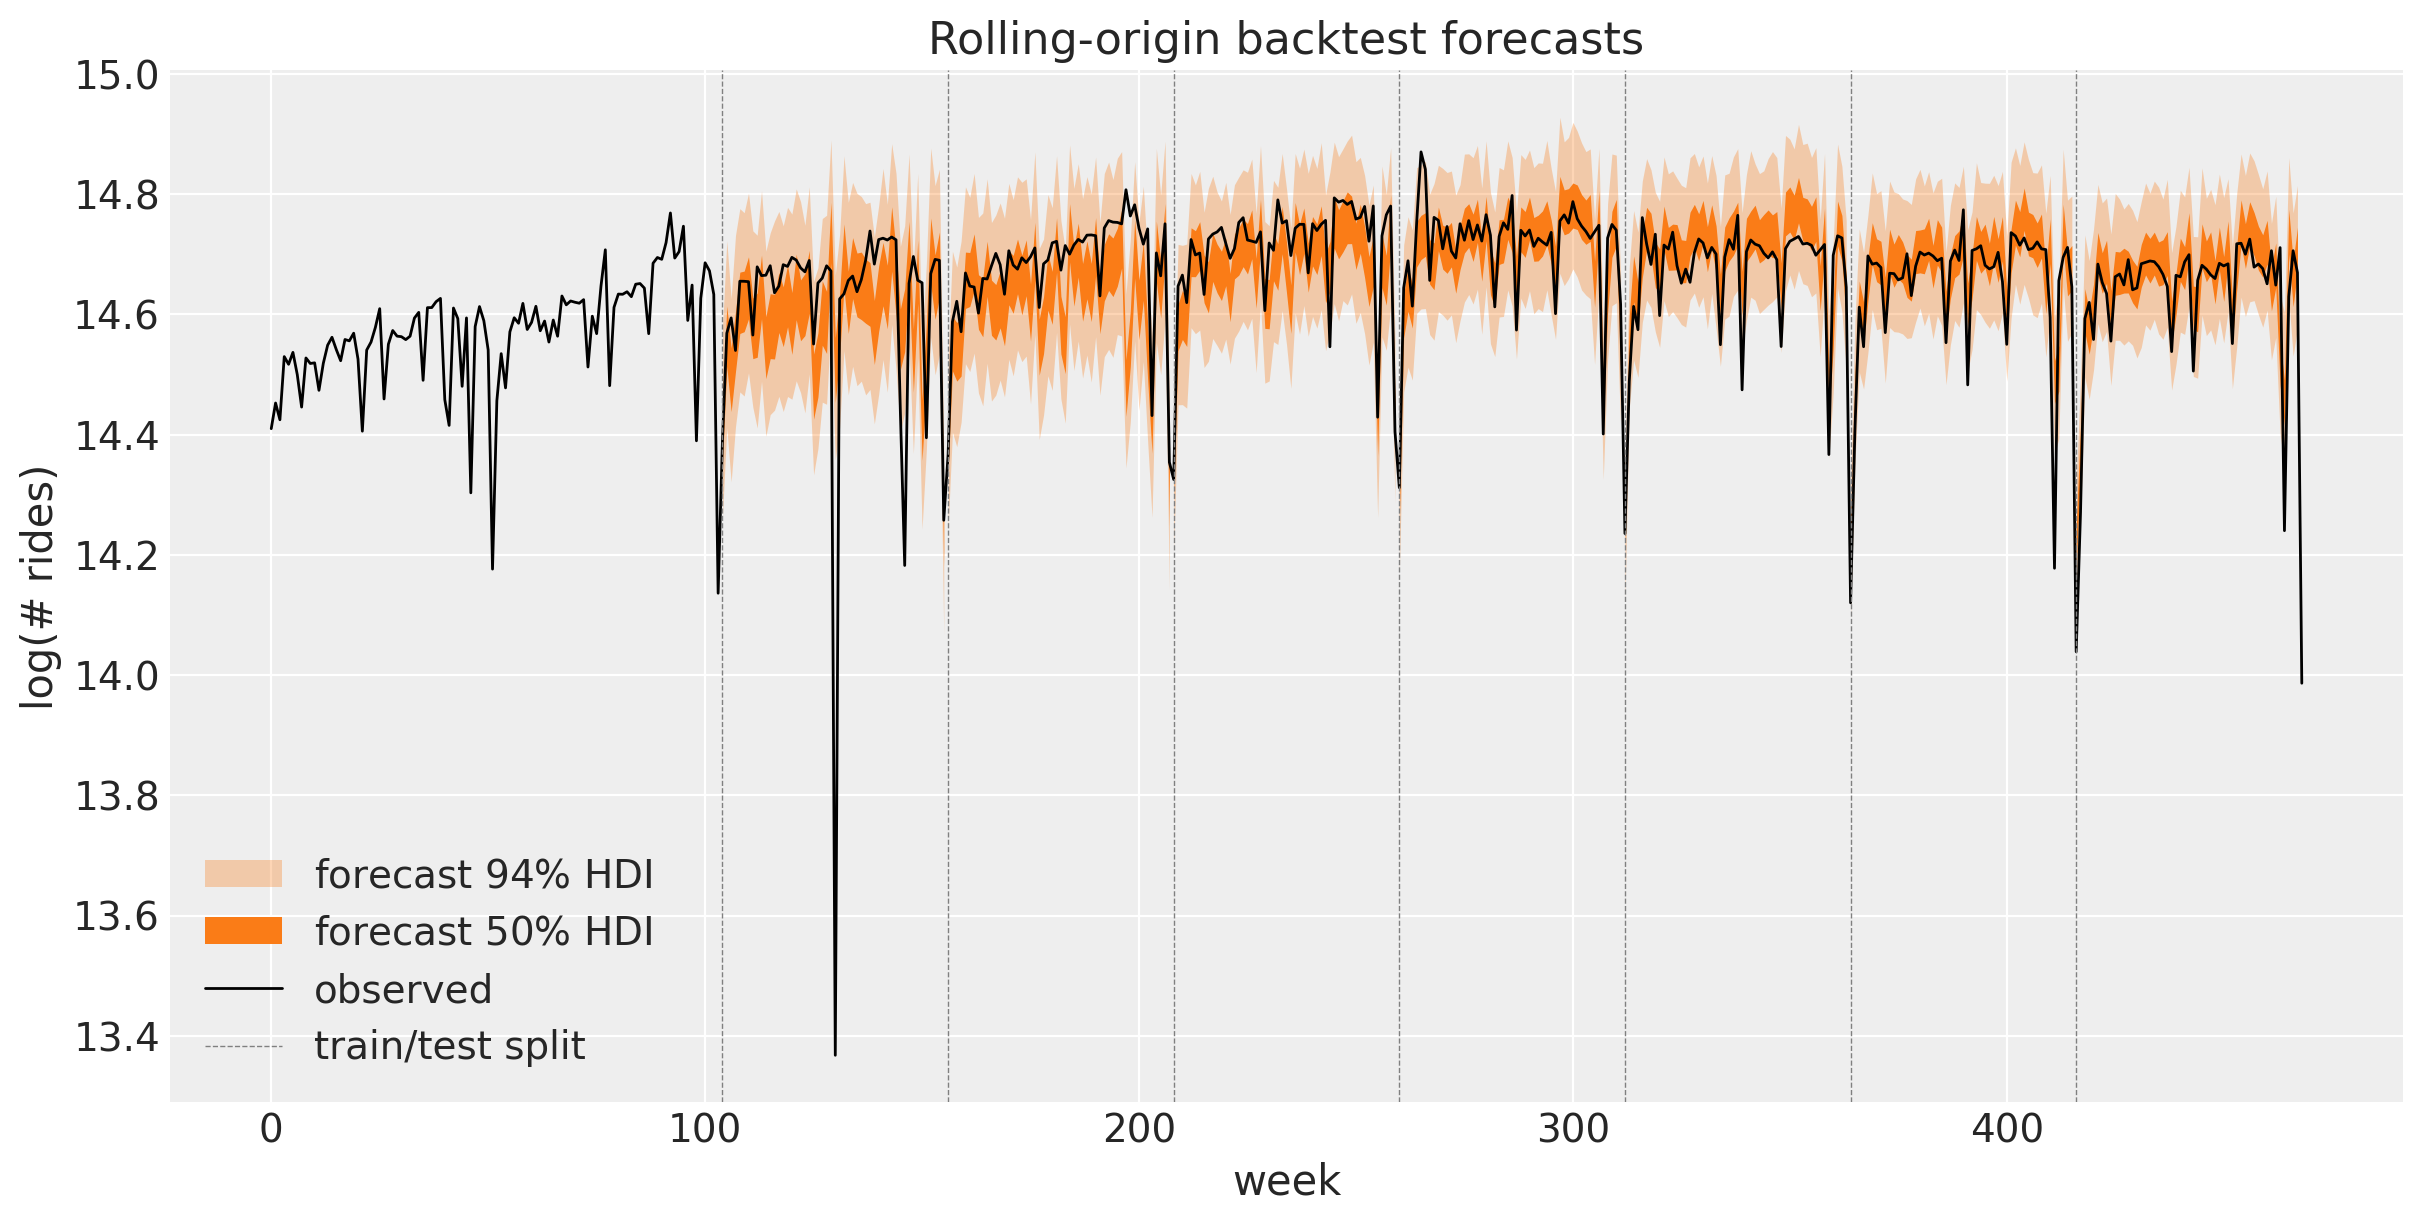

In [12]:
pc = None
for r in results:
    prediction = r.prediction
    if prediction is None:  # keep_predictions=True guarantees this never triggers
        continue
    weeks = time[r.t1 : r.t2].astype(float)
    idata = az.from_dict(
        {
            "posterior_predictive": {"obs": np.asarray(prediction[..., 0])[None]},
            "observed_data": {"obs": np.asarray(data[r.t1 : r.t2, 0])},
            "constant_data": {"week": weeks},
        },
        coords={"time": weeks},
        dims={"obs": ["time"], "week": ["time"]},
    )
    if pc is None:
        pc = az.plot_lm(
            idata,
            y="obs",
            x="week",
            ci_kind="hdi",
            ci_prob=(0.5, 0.94),
            smooth=False,
            visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
            figure_kwargs={"figsize": (12, 6)},
        )
    else:
        az.plot_lm(
            idata,
            y="obs",
            x="week",
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=(0.5, 0.94),
            smooth=False,
            visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
        )

if pc is None:
    msg = "no folds were plotted"
    raise ValueError(msg)
ax = pc.viz["figure"].item().axes[0]
# ax.collections holds the first fold's bands in ci_prob order: (0.5, 0.94).
band_50, band_94 = ax.collections[:2]
band_50.set_label(r"forecast $50\%$ HDI")
band_94.set_label(r"forecast $94\%$ HDI")
(obs_line,) = ax.plot(time, np.asarray(data[:, 0]), color="black", lw=1, label="observed")
split_lines = [
    ax.axvline(r.t1, color="gray", ls="--", lw=0.5, label="train/test split") for r in results
]
ax.set(title="Rolling-origin backtest forecasts", ylabel="log(# rides)")
ax.legend(handles=[band_94, band_50, obs_line, split_lines[0]], loc="lower left");

Within each fold the band fans out gently from its train/test split toward the right. That is the random-walk level diffusing: the level is a cumulative sum of drift increments (`level = jnp.cumsum(drift, axis=-2)`), and over the forecast horizon those future increments are drawn from the prior, so the predictive standard deviation grows like the square root of the horizon. The seasonal Fourier term is periodic and the Student-T observation noise is roughly constant, so this within-fold growth is dominated by the level diffusing. It is irreducible: more training data cannot make next year's random increments knowable.

Across folds the bands reset at each dashed split, where the model is refit and re-conditioned on all data up to that point, and their width stays stable from fold to fold. Each fold is fit with `num_steps=50_000` (the same budget as the main fit), so every expanding window converges and the inferred drift volatility is consistent. The bands therefore do not balloon as the series lengthens; under-training would leave the larger windows under-fit, inflate `drift_scale`, and widen the later folds spuriously.

The fit looks well calibrated, and the coverage plot further below makes that claim precise: the observed series stays inside the 94% band almost everywhere and inside the 50% band roughly half the time, close to the nominal levels. The sharp downward holiday spikes occasionally pierce the lower band, and that is by design: the heavy-tailed Student-T likelihood treats them as outliers rather than widening the whole band to swallow them.

### CRPS per fold

The per-fold CRPS shows the model generalizing better as it sees more history. The out-of-sample score is highest for the first, data-starved fold (trained on just the initial two years) and falls steeply as the expanding window grows, then flattens out near the in-sample level: more training data buys a sharper, better-calibrated one-year-ahead forecast, exactly as we would hope. The in-sample CRPS stays low and roughly flat across folds, because with `num_steps=50_000` each fold converges regardless of window length, so the fit quality does not drift.

The train-versus-test gap is therefore widest early, when data is scarce, and closes as history accumulates (the two curves even cross near the middle of the series). That closing gap is the healthy signature of a model whose generalization improves with more data, rather than an under-fit whose error would instead grow with window length. If you shrink `num_steps` you will see that healthy pattern break: both curves climb with the window as the larger folds stop converging.

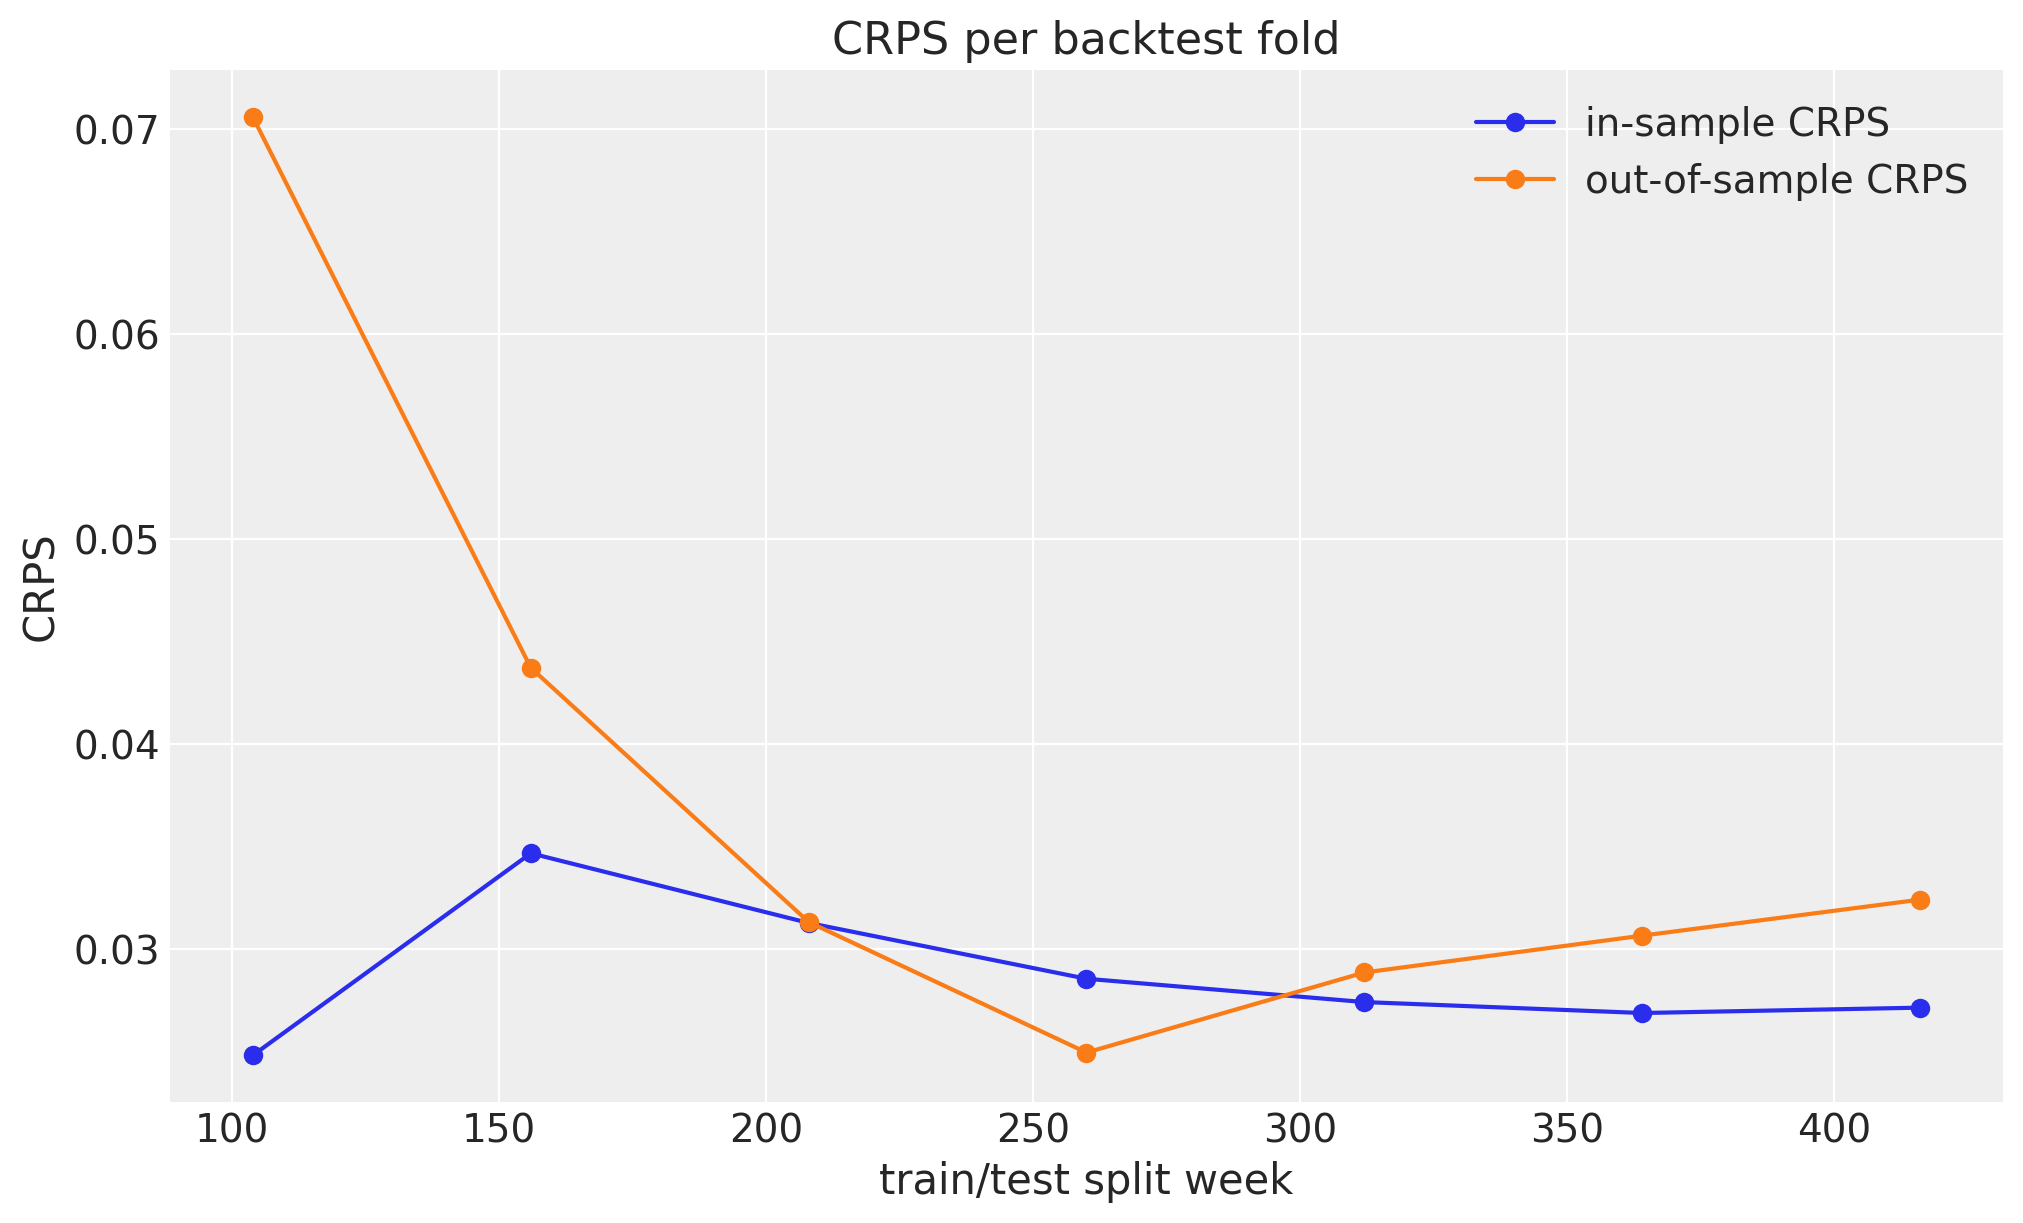

In [13]:
fig, ax = plt.subplots()
ax.plot(split_weeks, insample_crps, "o-", color="C0", label="in-sample CRPS")
ax.plot(split_weeks, oos_crps, "o-", color="C1", label="out-of-sample CRPS")
ax.legend()
ax.set(xlabel="train/test split week", ylabel="CRPS", title="CRPS per backtest fold");

### Forecast calibration

CRPS rewards sharp *and* calibrated forecasts but does not separate the two, so "the forecasts look calibrated" deserves its own number. We score the empirical **coverage** of each fold's out-of-sample bands: the fraction of held-out weeks that actually fall inside the central $50\%$ and $94\%$ prediction intervals. A well-calibrated forecast covers close to its nominal level, so the points should track the dashed reference lines. Points above mean the bands are too wide (under-confident); points below mean they are too narrow (over-confident). This is the quantitative version of the "stays inside the bands" eyeball check from the rolling-forecast plot.

A small caveat: `eval_coverage` measures coverage of the central quantile interval, while the plotted bands are arviz HDI. For the near-symmetric Student-T posterior predictive here the two nearly coincide, so this is a faithful check of the bands shown above.

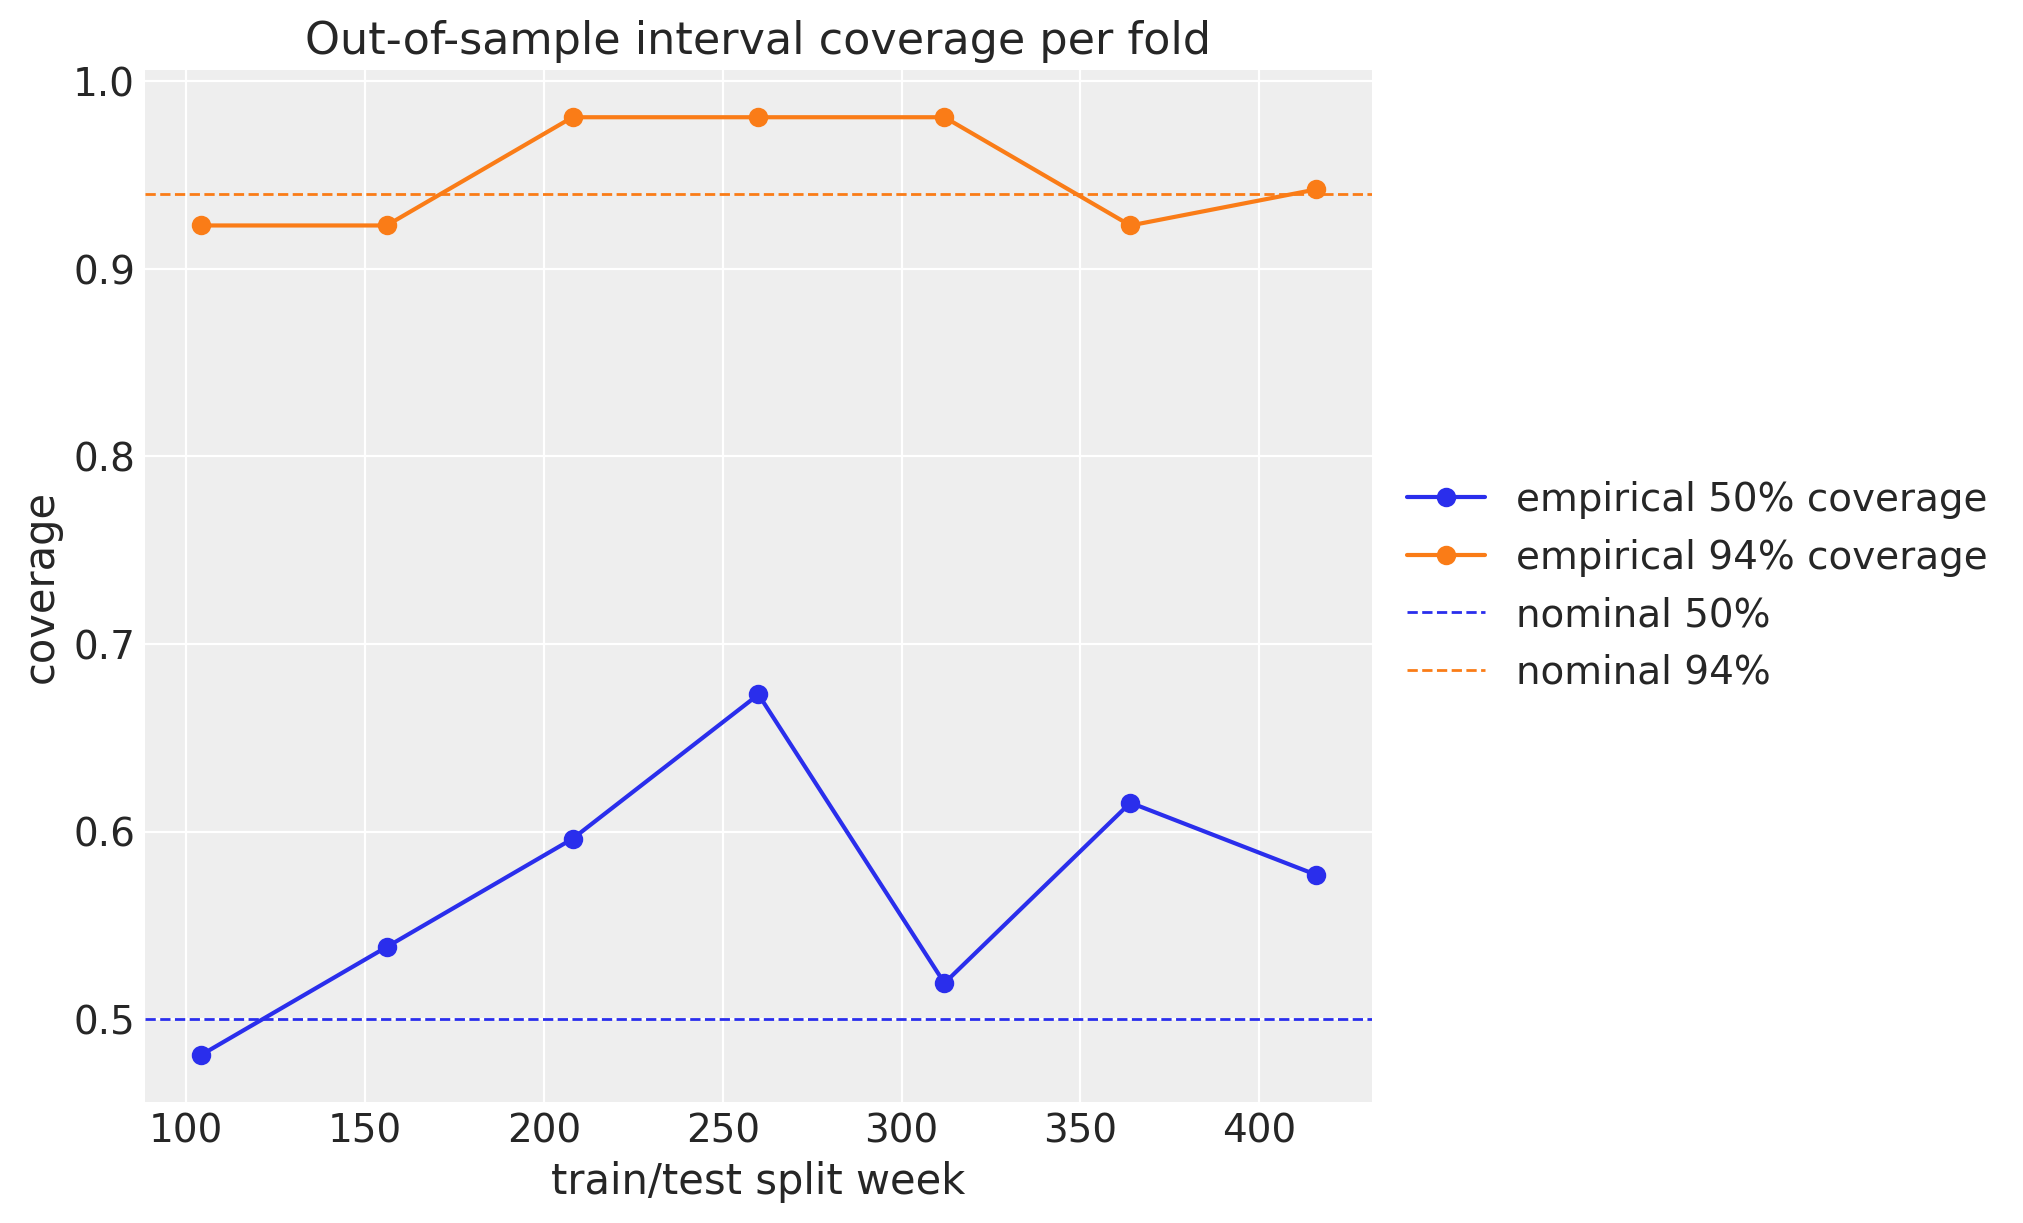

In [14]:
fig, ax = plt.subplots()
ax.plot(split_weeks, oos_cov_50, "o-", color="C0", label="empirical 50% coverage")
ax.plot(split_weeks, oos_cov_94, "o-", color="C1", label="empirical 94% coverage")
ax.axhline(0.5, color="C0", ls="--", lw=1, label="nominal 50%")
ax.axhline(0.94, color="C1", ls="--", lw=1, label="nominal 94%")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(
    xlabel="train/test split week",
    ylabel="coverage",
    title="Out-of-sample interval coverage per fold",
);

## Functional API

Everything so far went through the object-oriented `ForecastingModel`, but that class is only a thin shim over a functional core in `numpyro_forecast.functional`. The same model can be written as a plain function `(Horizon, covariates) -> None` that calls the free functions `time_series` and `predict` (the exact counterparts of the `self.time_series(...)` and `self.predict(...)` methods used above). The `Horizon` carries the train/forecast split that the class otherwise tracks as mutable state.

`forecasting_model(...)` then wraps that body into the standard `(covariates, data=None)` NumPyro model, so the result is a drop-in replacement for a `UnivariateForecaster()` instance: it works with `Forecaster`, `Predictive`, and `backtest` just the same. We rewrite the model below and confirm the two are interchangeable.

In [15]:
def univariate_model(h: Horizon, covariates: Array) -> None:
    """Functional twin of ``UnivariateForecaster.model``."""
    num_features = covariates.shape[-1]

    bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
    weight = numpyro.sample("weight", dist.Normal(0.0, 0.1).expand([num_features]).to_event(1))
    drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
    nu = numpyro.sample("nu", dist.Gamma(10.0, 2.0))
    sigma = numpyro.sample("sigma", dist.LogNormal(-5.0, 5.0))
    centered = numpyro.sample("centered", dist.Uniform(0.0, 1.0))

    drift = time_series(
        h,
        "drift",
        lambda: dist.Normal(0.0, drift_scale),
        reparam=LocScaleReparam(centered=centered),
    )
    level = jnp.cumsum(drift, axis=-2)
    regression = (weight * covariates).sum(axis=-1, keepdims=True)
    prediction = level + bias + regression

    predict(h, dist.StudentT(df=nu, loc=0.0, scale=sigma), prediction)


functional_model = forecasting_model(univariate_model)

To check the two are the same model, we draw a prior forward sample from each with the **same** `rng_subkey` and compare the `obs` site. Since `obs` sits downstream of every latent, matching `obs` draws imply the whole forward computation matched.

In [16]:
rng_key, rng_subkey = random.split(rng_key)

oop_obs = Predictive(UnivariateForecaster(), num_samples=100, return_sites=["obs"])(
    rng_subkey, covariates_train
)["obs"]
func_obs = Predictive(functional_model, num_samples=100, return_sites=["obs"])(
    rng_subkey, covariates_train
)["obs"]

print("identical forward samples:", bool(jnp.array_equal(oop_obs, func_obs)))
print("max abs difference:", float(jnp.max(jnp.abs(oop_obs - func_obs))))

identical forward samples: True
max abs difference: 0.0


The forward samples are bit-identical (maximum difference `0.0`): both models issue the same sample statements in the same order, so the random-number stream lines up exactly. The object-oriented class and the functional model are fully interchangeable, and you can reach for whichever style fits the problem.

## Next steps

This local level model with seasonality is a solid baseline. From here a few directions are natural: add holiday or special-event effects (dummy variables or Gaussian bump functions) for days the smooth seasonal basis cannot capture, or move to many related series at once. The last of these is the subject of the two companion notebooks, [hierarchical forecasting I](hierarchical_forecasting_1.html) and [II](hierarchical_forecasting_2.html), which generalize this same model to a panel of BART stations. See also Pyro's original [forecasting tutorial](https://pyro.ai/examples/forecasting_i.html).